In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import sys
import io, textwrap

In [3]:
# ============================================================================
# REUSABLE VISUALIZATION FUNCTIONS
# ============================================================================

def load_and_prepare_data(csv_path):
    """Load CSV and prepare data for visualization."""
    df = pd.read_csv(csv_path)
    
    # Convert columns to numeric
    for col in ["lr", "rank", "tr_from_name", "tr_actual", "accuracy",
                "negative_shift_count", "negative_shift_score",
                "positive_shift_count", "positive_shift_score"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    df["train_samples"] = df["tr_actual"].fillna(df["tr_from_name"])
    
    return df


def get_adapter_styles():
    """Define consistent colors and markers for adapters."""
    adapter_styles = {
        'lora': {'color': '#1f77b4', 'marker': 'o'},
        'uiortholora': {'color': '#2ca02c', 'marker': 's'},
        'vera': {'color': '#ff7f0e', 'marker': '^'},
        'randlora': {'color': '#d62728', 'marker': 'D'},
    }
    
    # Fallback for unknown adapters
    default_colors = plt.cm.tab10(np.linspace(0, 1, 10))
    default_markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']
    
    def get_style(adapter):
        return adapter_styles.get(adapter.lower(), {'color': 'gray', 'marker': 'o'})
    
    return get_style


def plot_accuracy_negshift_by_lr(df, output_prefix):
    """Plot 1: Combined subplots - Accuracy and Negative Shift per LR."""
    lrs = sorted(df["lr"].dropna().unique())
    adapters = sorted(df["adapter_type"].unique())
    get_style = get_adapter_styles()
    
    fig, axes = plt.subplots(len(lrs), 2, figsize=(14, 5 * len(lrs)), squeeze=False)
    fig.suptitle('Adapter Comparison: Accuracy & Negative Shift by Learning Rate', 
                 fontsize=14, fontweight='bold', y=1.01)
    
    for i, lr in enumerate(lrs):
        sub = df[df["lr"] == lr].copy().sort_values("train_samples")
        
        ax_acc = axes[i, 0]
        ax_neg = axes[i, 1]
        
        for adapter in adapters:
            sub_ad = sub[sub["adapter_type"] == adapter]
            if sub_ad.empty:
                continue
            
            style = get_style(adapter)
            
            ax_acc.plot(sub_ad["train_samples"], sub_ad["accuracy"],
                        marker=style['marker'], color=style['color'],
                        label=adapter, linewidth=2, markersize=8)
            
            ax_neg.plot(sub_ad["train_samples"], sub_ad["negative_shift_score"],
                        marker=style['marker'], color=style['color'],
                        label=adapter, linewidth=2, markersize=8)
        
        ax_acc.set_xlabel("Training Samples")
        ax_acc.set_ylabel("Accuracy")
        ax_acc.set_title(f"Accuracy (LR={lr:.0e})")
        ax_acc.legend(loc='best')
        ax_acc.grid(True, alpha=0.3)
        ax_acc.set_xscale('log')
        
        ax_neg.set_xlabel("Training Samples")
        ax_neg.set_ylabel("Negative Shift Score")
        ax_neg.set_title(f"Negative Shift Score (LR={lr:.0e})")
        ax_neg.legend(loc='best')
        ax_neg.grid(True, alpha=0.3)
        ax_neg.set_xscale('log')
    
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_acc_negshift_by_lr.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_tradeoff_scatter(df, output_prefix):
    """Plot 2: Accuracy vs Negative Shift Trade-off (scatter plot per LR)."""
    lrs = sorted(df["lr"].dropna().unique())
    adapters = sorted(df["adapter_type"].unique())
    get_style = get_adapter_styles()
    
    fig, axes = plt.subplots(1, len(lrs), figsize=(6 * len(lrs), 5), squeeze=False)
    fig.suptitle('Trade-off: Accuracy vs Negative Shift Score', 
                  fontsize=14, fontweight='bold', y=1.02)
    
    for i, lr in enumerate(lrs):
        ax = axes[0, i]
        sub = df[df["lr"] == lr]
        
        for adapter in adapters:
            sub_ad = sub[sub["adapter_type"] == adapter]
            if sub_ad.empty:
                continue
            
            style = get_style(adapter)
            
            # Size points by training samples
            sizes = 50 + (sub_ad["train_samples"] / sub_ad["train_samples"].max()) * 200
            
            scatter = ax.scatter(sub_ad["negative_shift_score"], sub_ad["accuracy"],
                                c=[style['color']] * len(sub_ad),
                                marker=style['marker'],
                                s=sizes,
                                label=adapter,
                                alpha=0.7,
                                edgecolors='black',
                                linewidths=0.5)
        
        ax.set_xlabel("Negative Shift Score (lower is better)")
        ax.set_ylabel("Accuracy (higher is better)")
        ax.set_title(f"LR={lr:.0e}")
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        # Add ideal direction arrow
        ax.annotate('', xy=(ax.get_xlim()[0] + 0.1, ax.get_ylim()[1] - 0.02),
                    xytext=(ax.get_xlim()[1] - 0.1, ax.get_ylim()[0] + 0.02),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, ls='--'))
        ax.text(0.05, 0.95, '← Better', transform=ax.transAxes, fontsize=9, 
                color='gray', va='top')
    
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_tradeoff_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_radar_comparison(df, lr, output_prefix):
    """Plot radar/spider chart comparing adapters at a specific LR."""
    sub = df[df["lr"] == lr]
    adapters = sorted(df["adapter_type"].unique())
    get_style = get_adapter_styles()
    
    # Metrics to compare (normalized)
    metrics = ['accuracy', 'negative_shift_score', 'positive_shift_score']
    metric_labels = ['Accuracy\n(↑ better)', 'Neg Shift\n(↓ better)', 'Pos Shift\n(↑ better)']
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]  # Complete the loop
    
    for adapter in adapters:
        sub_ad = sub[sub["adapter_type"] == adapter]
        if sub_ad.empty:
            continue
        
        # Use mean across training samples for this comparison
        values = []
        for m in metrics:
            val = sub_ad[m].mean()
            # Normalize: for negative_shift, invert so higher is better
            if m == 'negative_shift_score':
                val = 1 - (val / df[m].max()) if df[m].max() > 0 else 0
            else:
                val = val / df[m].max() if df[m].max() > 0 else 0
            values.append(val)
        
        values += values[:1]  # Complete the loop
        
        style = get_style(adapter)
        ax.plot(angles, values, 'o-', linewidth=2, label=adapter,
                color=style['color'], markersize=6)
        ax.fill(angles, values, alpha=0.15, color=style['color'])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels)
    ax.set_title(f'Adapter Comparison at LR={lr:.0e}\n(Normalized, outer = better)', 
                 fontsize=12, fontweight='bold', y=1.1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    plt.tight_layout()
    plt.savefig(f'{output_prefix}_radar_lr{lr:.0e}.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_all_radars(df, output_prefix):
    """Plot radar charts for all learning rates."""
    lrs = sorted(df["lr"].dropna().unique())
    for lr in lrs:
        plot_radar_comparison(df, lr, output_prefix)


def print_summary_tables(df, model_name):
    """Print summary tables for best configurations."""
    adapters = sorted(df["adapter_type"].unique())
    
    print("\n" + "=" * 90)
    print(f"SUMMARY: {model_name} - Best Configuration per Adapter (by Accuracy)")
    print("=" * 90)
    
    for adapter in adapters:
        adapter_data = df[df['adapter_type'] == adapter]
        if len(adapter_data) > 0:
            best_row = adapter_data.loc[adapter_data['accuracy'].idxmax()]
            print(f"\n{adapter}:")
            print(f"  Best Accuracy: {best_row['accuracy']:.4f}")
            print(f"  Negative Shift: {best_row['negative_shift_score']:.4f}")
            print(f"  Training Samples: {int(best_row['train_samples'])}")
            print(f"  Learning Rate: {best_row['lr']:.0e}")
    
    print("\n" + "=" * 90)
    print(f"SUMMARY: {model_name} - Best Configuration per Adapter (by Lowest Negative Shift)")
    print("=" * 90)
    
    for adapter in adapters:
        adapter_data = df[df['adapter_type'] == adapter]
        if len(adapter_data) > 0:
            best_row = adapter_data.loc[adapter_data['negative_shift_score'].idxmin()]
            print(f"\n{adapter}:")
            print(f"  Accuracy: {best_row['accuracy']:.4f}")
            print(f"  Lowest Negative Shift: {best_row['negative_shift_score']:.4f}")
            print(f"  Training Samples: {int(best_row['train_samples'])}")
            print(f"  Learning Rate: {best_row['lr']:.0e}")


def run_full_analysis(csv_path, output_prefix, model_name):
    """
    Run complete analysis pipeline for a given CSV file.
    
    Args:
        csv_path: Path to the CSV file
        output_prefix: Prefix for output files (e.g., 'gemma', 'llama-3b')
        model_name: Model name for display (e.g., 'Gemma-3-12B-IT')
    """
    print(f"\n{'='*90}")
    print(f"Running analysis for {model_name}")
    print(f"CSV: {csv_path}")
    print(f"Output prefix: {output_prefix}")
    print(f"{'='*90}\n")
    
    # Load and prepare data
    df = load_and_prepare_data(csv_path)
    
    # Generate all plots
    plot_accuracy_negshift_by_lr(df, output_prefix)
    plot_tradeoff_scatter(df, output_prefix)
    plot_all_radars(df, output_prefix)
    
    # Print summary tables
    print_summary_tables(df, model_name)
    
    print(f"\n{'='*90}")
    print(f"Analysis complete for {model_name}")
    print(f"{'='*90}\n")

print("✓ Reusable visualization functions loaded successfully!")

✓ Reusable visualization functions loaded successfully!



Running analysis for Gemma-3-12B-IT
CSV: gemma_adapter_results.csv
Output prefix: graphs/gemma



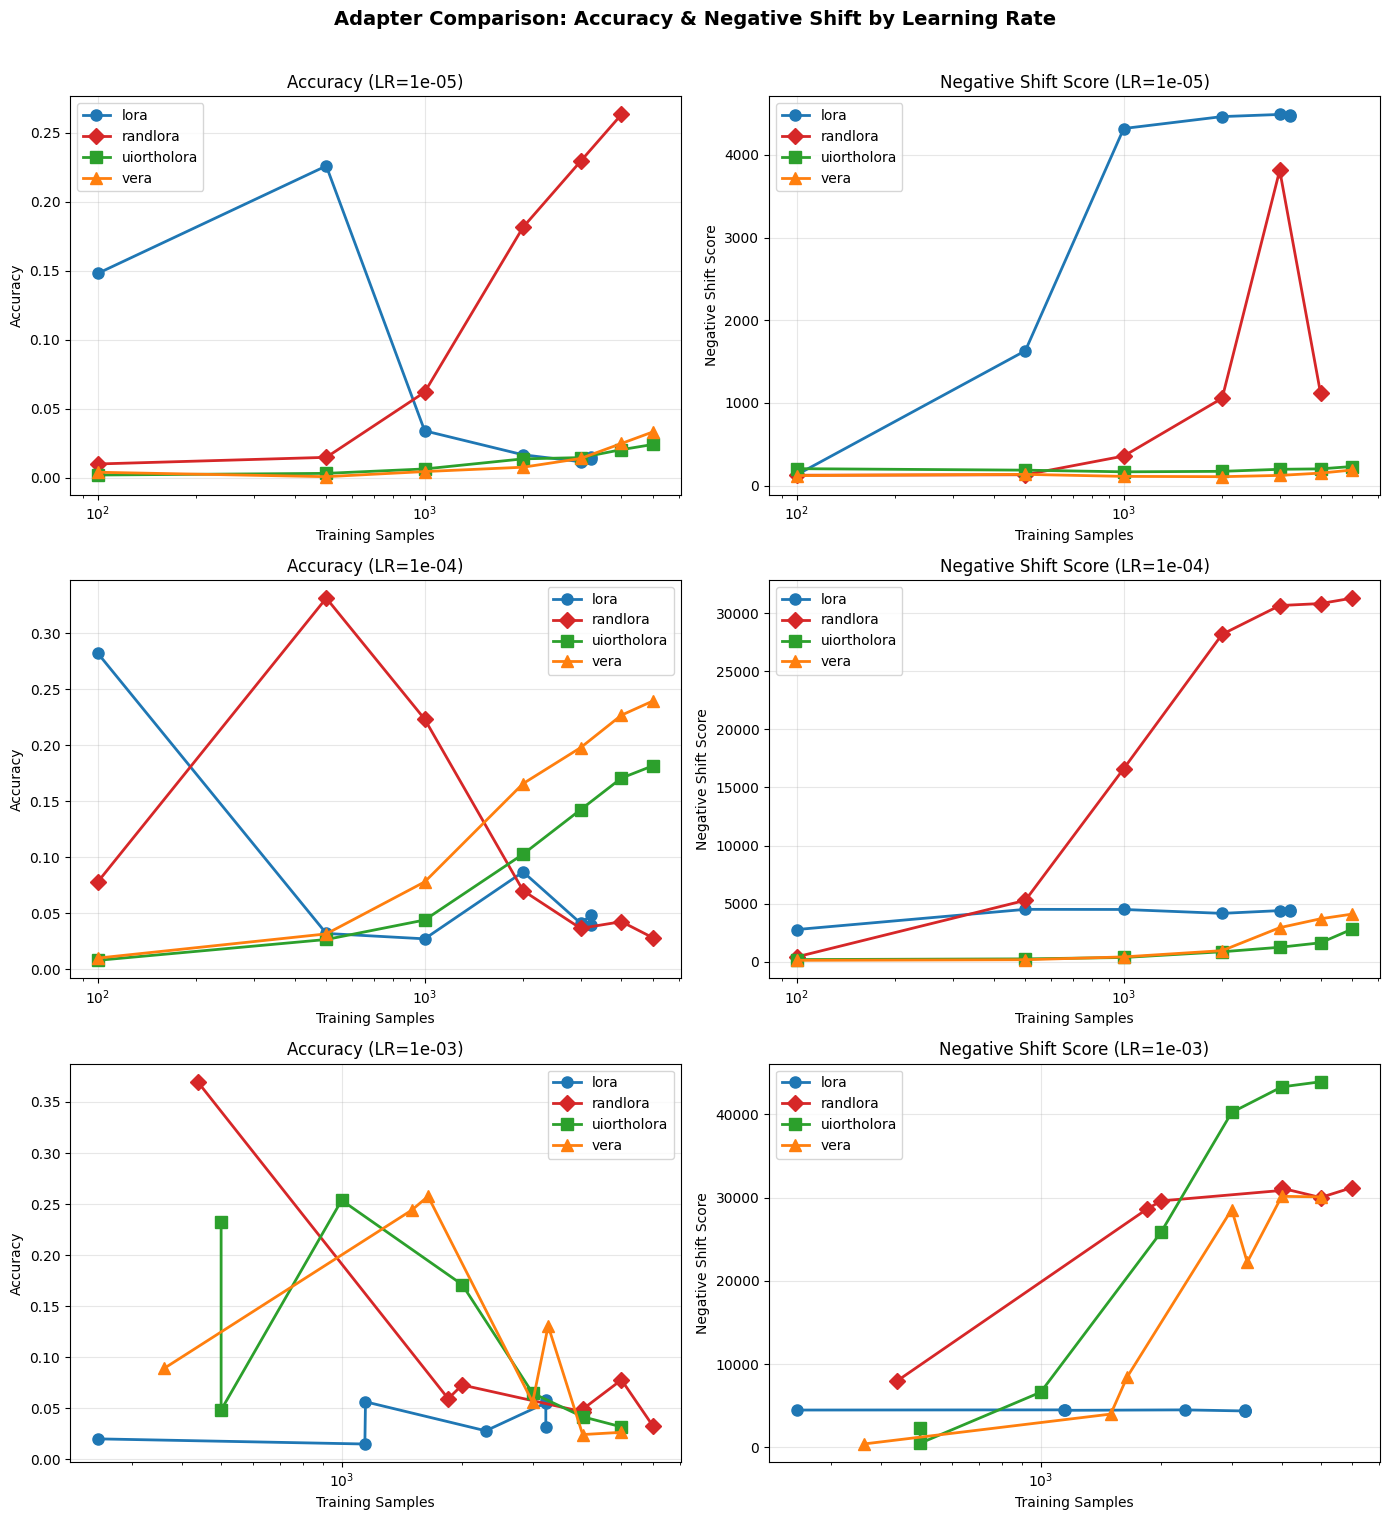

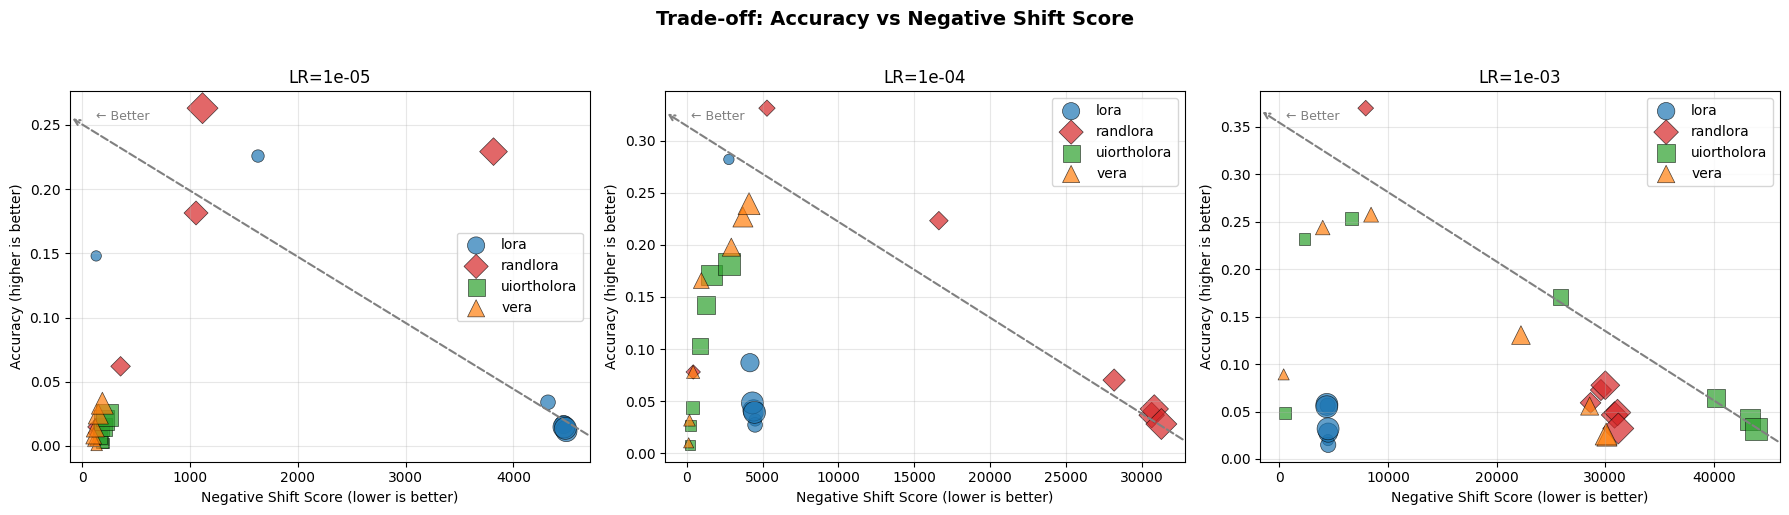

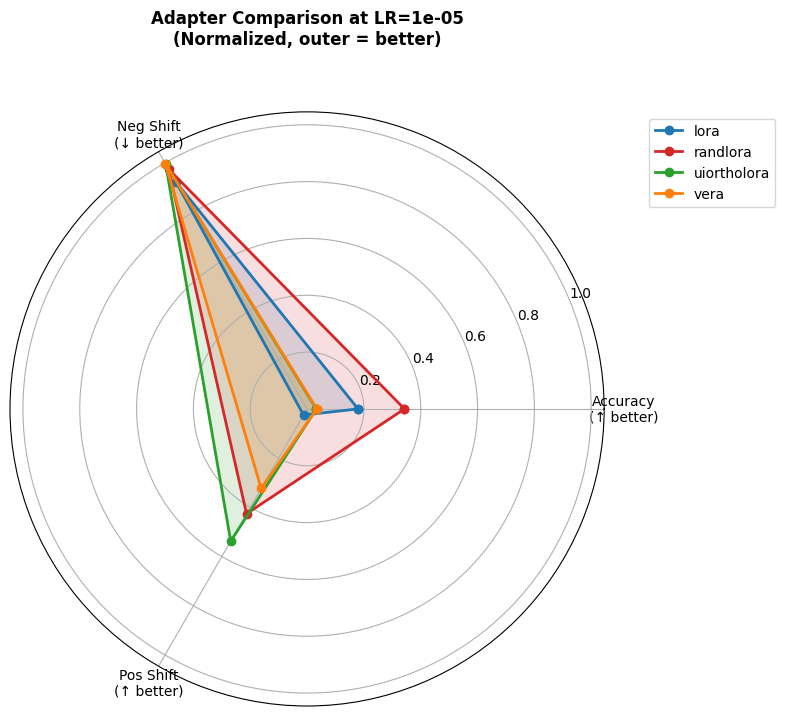

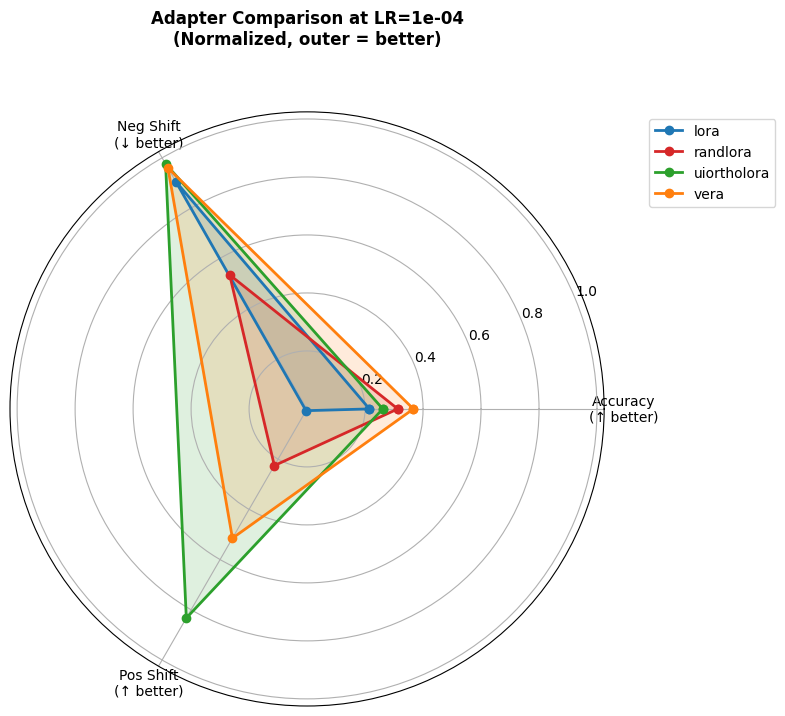

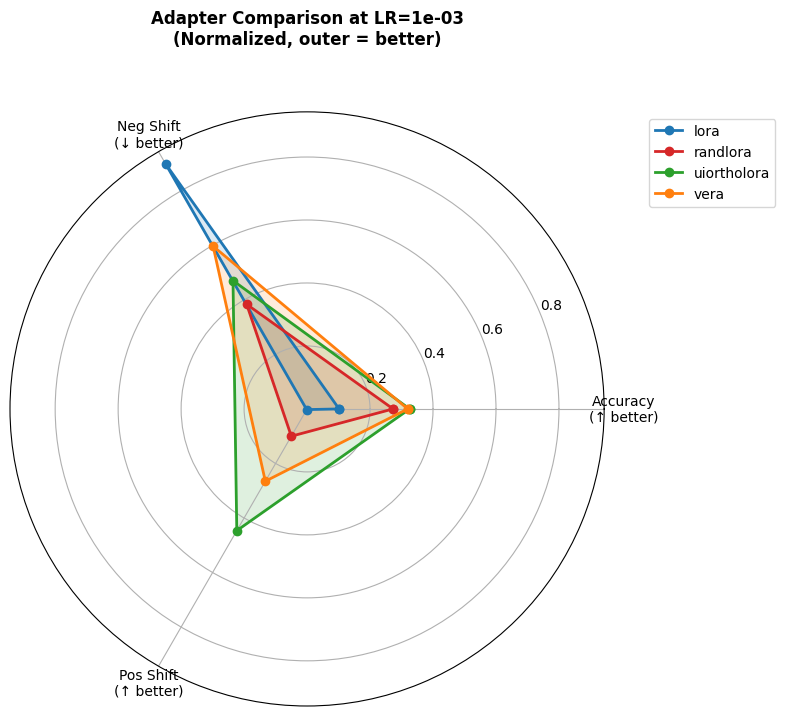


SUMMARY: Gemma-3-12B-IT - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.2820
  Negative Shift: 2771.6000
  Training Samples: 100
  Learning Rate: 1e-04

randlora:
  Best Accuracy: 0.3698
  Negative Shift: 7953.2000
  Training Samples: 437
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.2537
  Negative Shift: 6624.2000
  Training Samples: 1000
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.2575
  Negative Shift: 8448.2000
  Training Samples: 1644
  Learning Rate: 1e-03

SUMMARY: Gemma-3-12B-IT - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.1480
  Lowest Negative Shift: 131.4000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0100
  Lowest Negative Shift: 125.6000
  Training Samples: 100
  Learning Rate: 1e-05

uiortholora:
  Accuracy: 0.0064
  Lowest Negative Shift: 166.8000
  Training Samples: 1000
  Learning Rate: 1e-05

vera:
  Accuracy: 0.0076
  Lowest Negative Shift: 108.1000
  Training Sa

In [4]:
# ============================================================================
# GEMMA-3-12B-IT ANALYSIS
# ============================================================================

run_full_analysis(
    csv_path="gemma_adapter_results.csv",
    output_prefix="graphs/gemma",
    model_name="Gemma-3-12B-IT"
)


Running analysis for Llama-3.2-3B-Instruct
CSV: llama-3b_adapter_results.csv
Output prefix: graphs/llama-3b



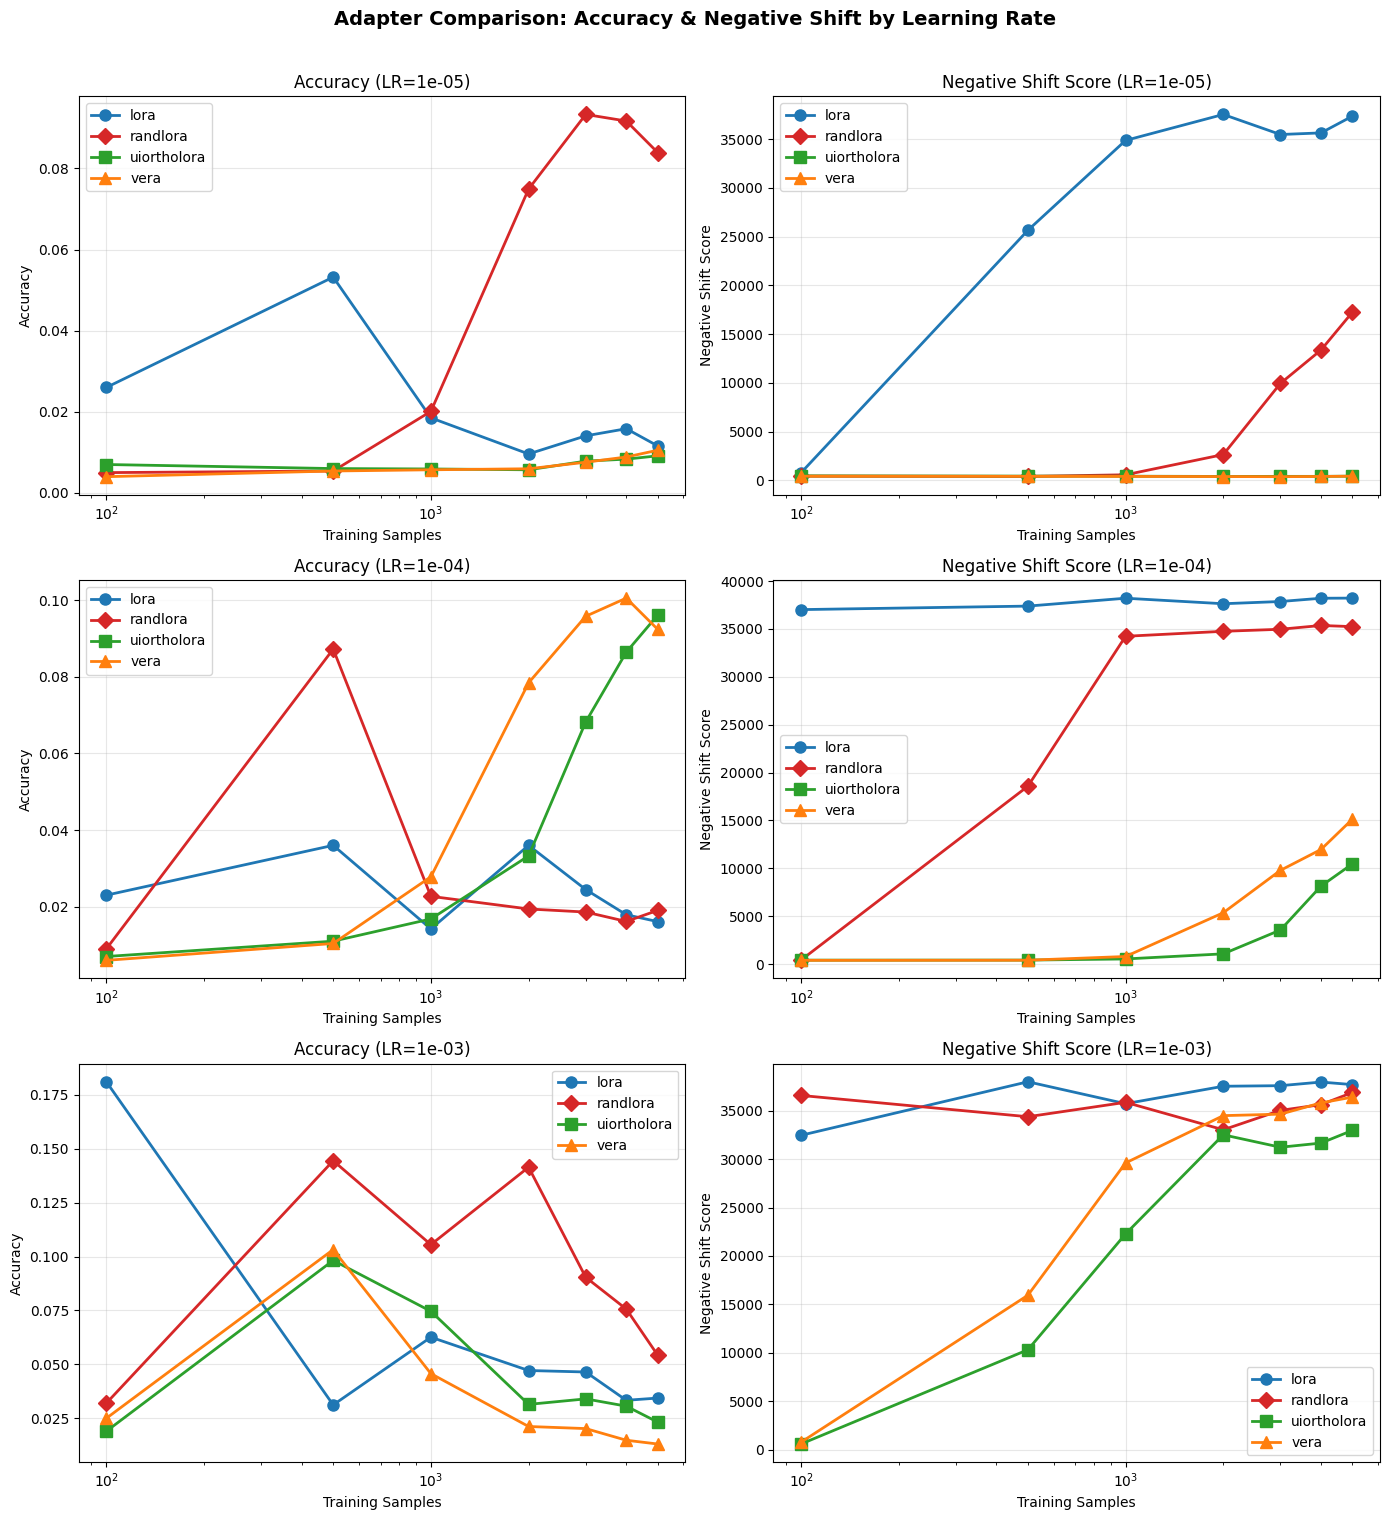

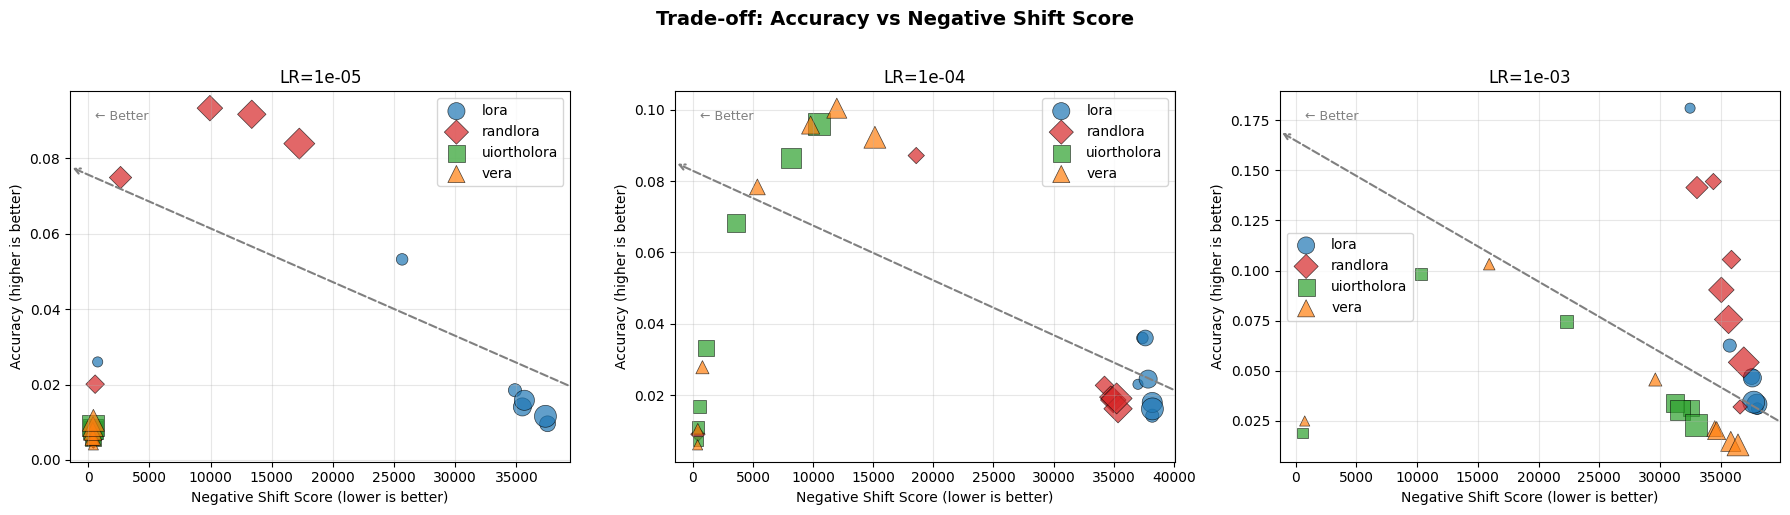

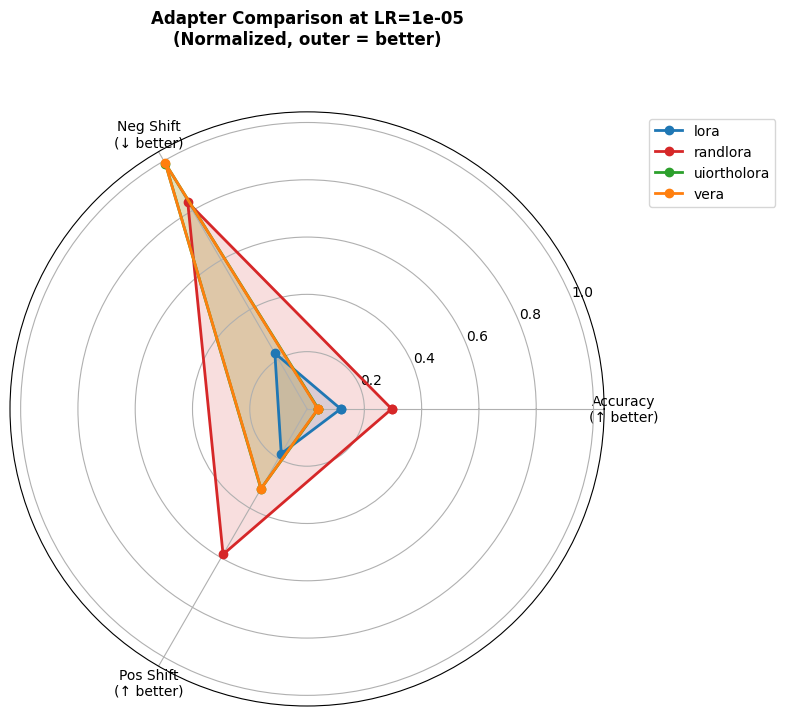

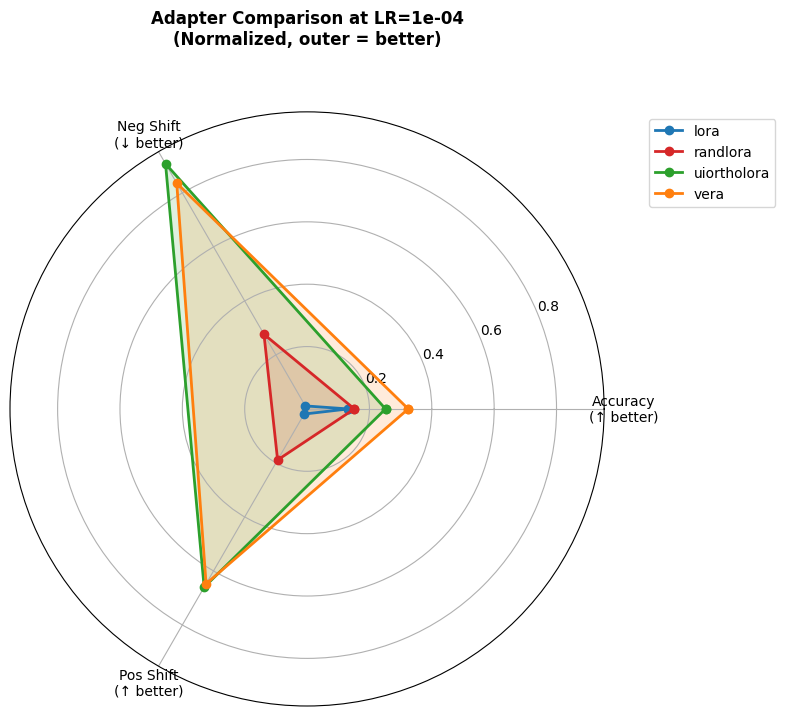

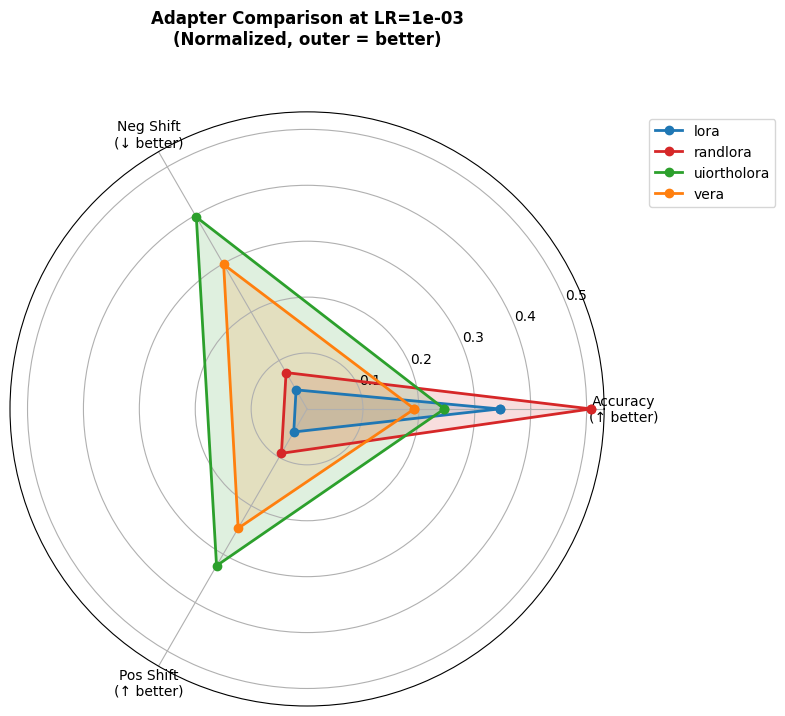


SUMMARY: Llama-3.2-3B-Instruct - Best Configuration per Adapter (by Accuracy)

lora:
  Best Accuracy: 0.1810
  Negative Shift: 32466.0000
  Training Samples: 100
  Learning Rate: 1e-03

randlora:
  Best Accuracy: 0.1444
  Negative Shift: 34385.5000
  Training Samples: 500
  Learning Rate: 1e-03

uiortholora:
  Best Accuracy: 0.0982
  Negative Shift: 10307.2000
  Training Samples: 500
  Learning Rate: 1e-03

vera:
  Best Accuracy: 0.1032
  Negative Shift: 15940.0000
  Training Samples: 500
  Learning Rate: 1e-03

SUMMARY: Llama-3.2-3B-Instruct - Best Configuration per Adapter (by Lowest Negative Shift)

lora:
  Accuracy: 0.0260
  Lowest Negative Shift: 772.4000
  Training Samples: 100
  Learning Rate: 1e-05

randlora:
  Accuracy: 0.0054
  Lowest Negative Shift: 398.5000
  Training Samples: 500
  Learning Rate: 1e-05

uiortholora:
  Accuracy: 0.0057
  Lowest Negative Shift: 394.8000
  Training Samples: 2000
  Learning Rate: 1e-05

vera:
  Accuracy: 0.0076
  Lowest Negative Shift: 371.00

In [5]:
# ============================================================================
# LLAMA-3.2-3B-INSTRUCT ANALYSIS
# ============================================================================

run_full_analysis(
    csv_path="llama-3b_adapter_results.csv",
    output_prefix="graphs/llama-3b",
    model_name="Llama-3.2-3B-Instruct"
)

In [6]:
stop

NameError: name 'stop' is not defined

# Template for Adding New Datasets

To add analysis for a new model (e.g., llama-8b), simply copy the cell below and update the parameters:

```python
# ============================================================================
# LLAMA-8B ANALYSIS (EXAMPLE)
# ============================================================================

run_full_analysis(
    csv_path="llama-8b_adapter_results.csv",     # Your CSV file
    output_prefix="graphs/llama-8b",             # Output folder/prefix
    model_name="Llama-8B"                        # Display name
)
```

The function will automatically:
- Load and prepare the data
- Generate all visualization plots
- Save graphs with the specified prefix
- Print summary tables

After filtering to LoRA r=4: 82 rows
LoRA rows: 21
Unique LoRA ranks: [4.]


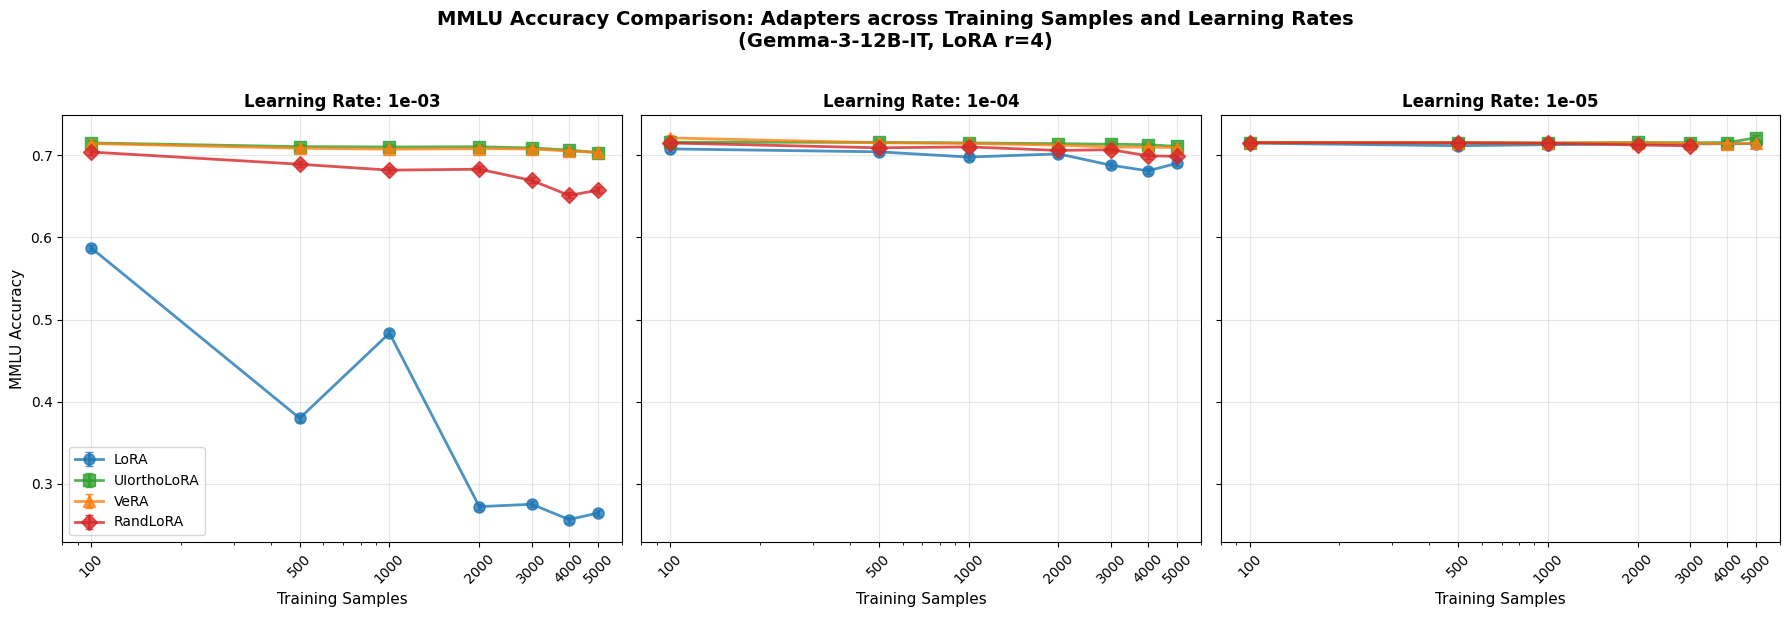

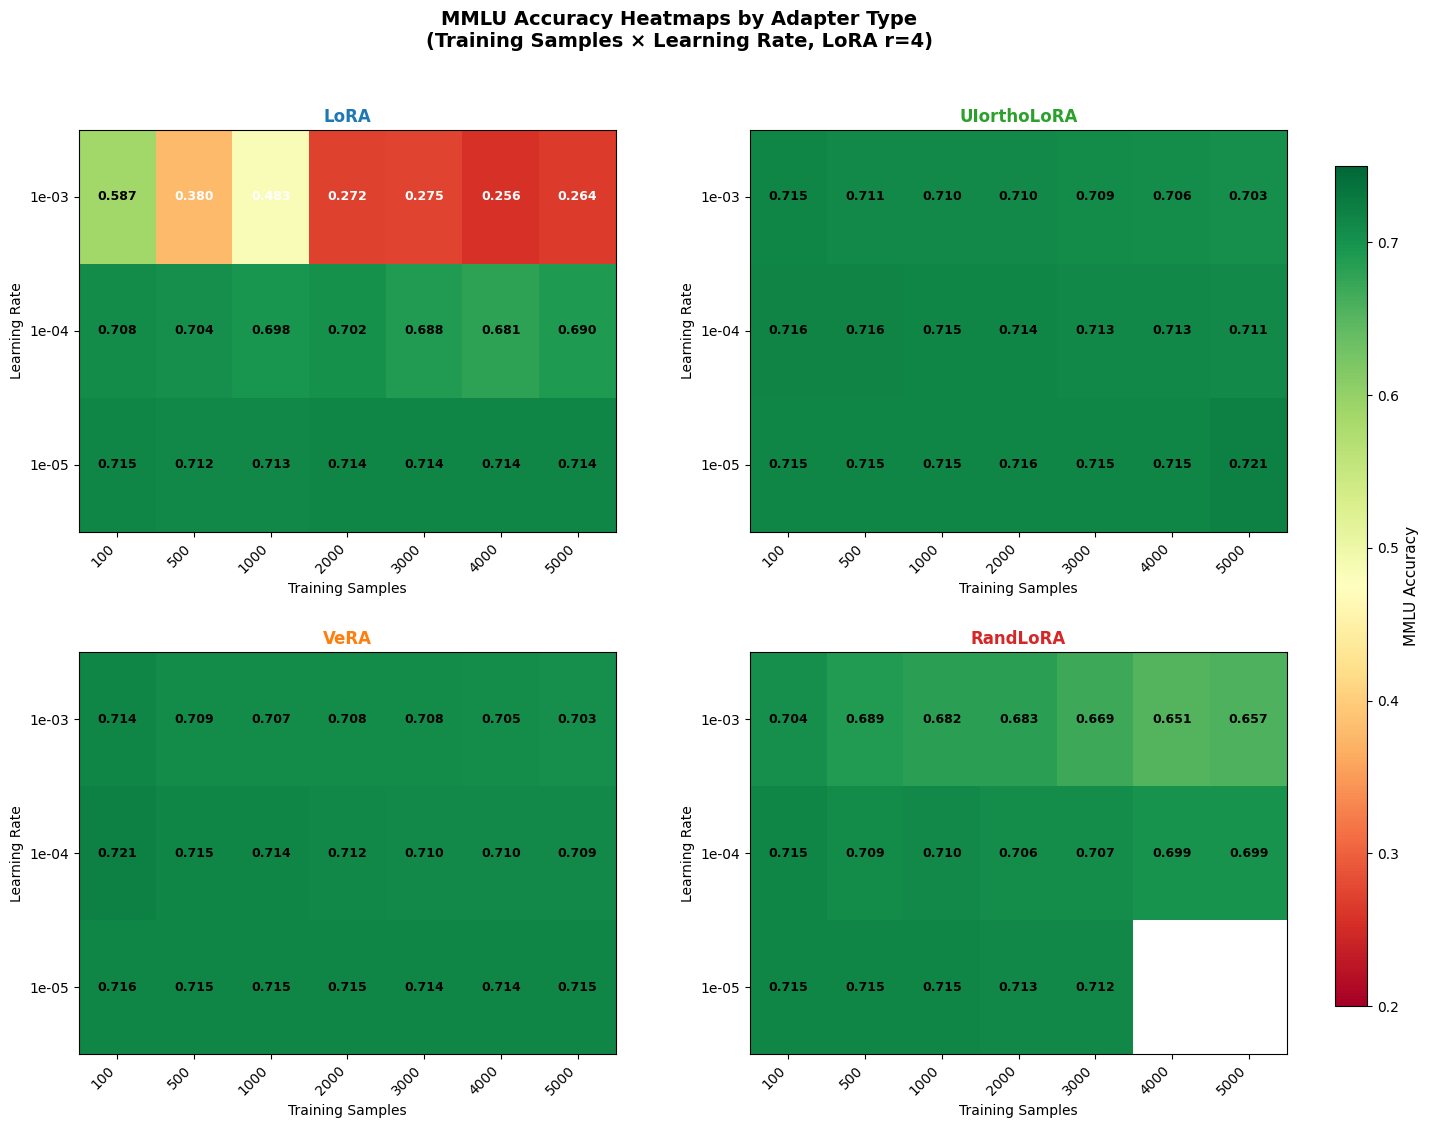

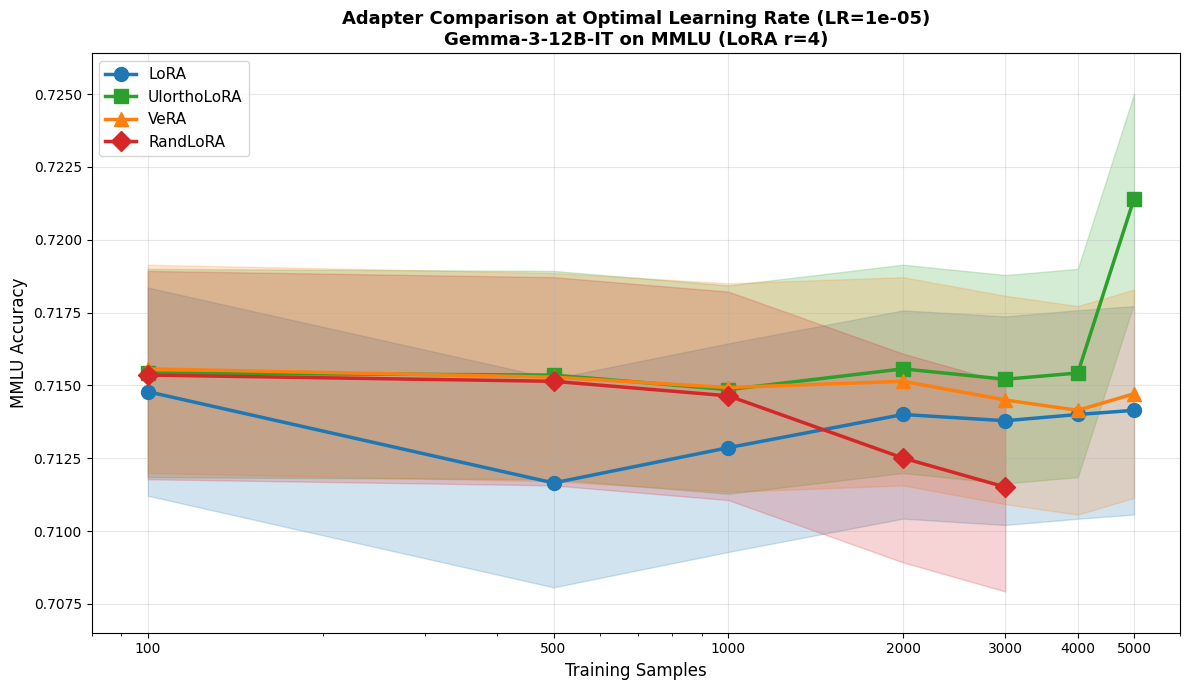


SUMMARY: Best Configuration per Adapter (LoRA r=4 only)

LoRA:
  Best Accuracy: 0.7148 ± 0.0036
  Training Samples: 100
  Learning Rate: 1e-05
  Rank: 4

UIorthoLoRA:
  Best Accuracy: 0.7214 ± 0.0036
  Training Samples: 5000
  Learning Rate: 1e-05

VeRA:
  Best Accuracy: 0.7211 ± 0.0036
  Training Samples: 100
  Learning Rate: 1e-04
  Rank: 1024

RandLoRA:
  Best Accuracy: 0.7154 ± 0.0036
  Training Samples: 100
  Learning Rate: 1e-05
  Rank: 512

COMPARISON: All Adapters at Same Configurations (LoRA r=4 only)

--- Learning Rate: 1e-03 ---

  Training Samples: 100
    LoRA        : 0.5872
    UIorthoLoRA : 0.7150
    VeRA        : 0.7143
    RandLoRA    : 0.7040

  Training Samples: 500
    LoRA        : 0.3799
    UIorthoLoRA : 0.7105
    VeRA        : 0.7086
    RandLoRA    : 0.6891

  Training Samples: 1000
    LoRA        : 0.4835
    UIorthoLoRA : 0.7102
    VeRA        : 0.7074
    RandLoRA    : 0.6819

  Training Samples: 2000
    LoRA        : 0.2722
    UIorthoLoRA : 0.7104
 

In [ ]:
# Read data from file
csv_file = "../results/mmlu/mmlu/mmlu_summary.csv"
df = pd.read_csv(csv_file)

# Parse model name to extract adapter type, training samples, learning rate, AND rank
def parse_model_name(name):
    # Extract adapter type
    if '_uiortholora_' in name:
        adapter = 'UIorthoLoRA'
    elif '_randlora_' in name:
        adapter = 'RandLoRA'
    elif '_vera_' in name:
        adapter = 'VeRA'
    elif '_lora_' in name:
        adapter = 'LoRA'
    else:
        adapter = 'Unknown'
    
    # Extract training samples
    tr_match = re.search(r'_tr(\d+)_', name)
    train_samples = int(tr_match.group(1)) if tr_match else None
    
    # Extract learning rate
    lr_match = re.search(r'_lr([\d\w\-]+)$', name)
    if lr_match:
        lr_str = lr_match.group(1)
        lr = float(lr_str.replace('e-', 'e-'))
    else:
        lr = None
    
    # Extract rank (for LoRA: r3, r4; for VeRA: r1024; for RandLoRA: r512)
    rank_match = re.search(r'_r(\d+)_', name)
    rank = int(rank_match.group(1)) if rank_match else None
    
    return adapter, train_samples, lr, rank

# Apply parsing
df['adapter'], df['train_samples'], df['lr'], df['rank'] = zip(*df['model_name'].apply(parse_model_name))

# Filter out any parsing errors
df = df[df['adapter'] != 'Unknown']
df = df[df['train_samples'].notna()]
df = df[df['lr'].notna()]

# Filter: Keep only LoRA with rank=4, and all other adapters
df = df[~((df['adapter'] == 'LoRA') & (df['rank'] != 4))]

print(f"After filtering to LoRA r=4: {len(df)} rows")
print(f"LoRA rows: {len(df[df['adapter'] == 'LoRA'])}")
print(f"Unique LoRA ranks: {df[df['adapter'] == 'LoRA']['rank'].unique()}")

# Define colors and markers for adapters
adapter_colors = {
    'LoRA': '#1f77b4',
    'UIorthoLoRA': '#2ca02c',
    'VeRA': '#ff7f0e',
    'RandLoRA': '#d62728'
}

adapter_markers = {
    'LoRA': 'o',
    'UIorthoLoRA': 's',
    'VeRA': '^',
    'RandLoRA': 'D'
}

# Get unique values
learning_rates = sorted(df['lr'].unique(), reverse=True)
train_samples_list = sorted(df['train_samples'].unique())
adapters = ['LoRA', 'UIorthoLoRA', 'VeRA', 'RandLoRA']

# Create figure with subplots for each learning rate
fig, axes = plt.subplots(1, len(learning_rates), figsize=(6*len(learning_rates), 6), sharey=True)
if len(learning_rates) == 1:
    axes = [axes]

fig.suptitle('MMLU Accuracy Comparison: Adapters across Training Samples and Learning Rates\n(Gemma-3-12B-IT, LoRA r=4)', 
             fontsize=14, fontweight='bold', y=1.02)

for idx, lr in enumerate(learning_rates):
    ax = axes[idx]
    lr_data = df[df['lr'] == lr]
    
    for adapter in adapters:
        adapter_data = lr_data[lr_data['adapter'] == adapter]
        if len(adapter_data) > 0:
            adapter_data = adapter_data.sort_values('train_samples')
            
            ax.errorbar(
                adapter_data['train_samples'], 
                adapter_data['mmlu_acc'],
                yerr=adapter_data['mmlu_acc_stderr'],
                label=adapter,
                color=adapter_colors[adapter],
                marker=adapter_markers[adapter],
                markersize=8,
                capsize=3,
                linewidth=2,
                alpha=0.8
            )
    
    ax.set_xlabel('Training Samples', fontsize=11)
    ax.set_title(f'Learning Rate: {lr:.0e}', fontsize=12, fontweight='bold')
    ax.set_xscale('log')
    ax.set_xticks(train_samples_list)
    ax.set_xticklabels([str(int(x)) for x in train_samples_list], rotation=45)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(min(train_samples_list) * 0.8, max(train_samples_list) * 1.2)

axes[0].set_ylabel('MMLU Accuracy', fontsize=11)
axes[0].legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig('adapter_comparison_by_lr.png', dpi=150, bbox_inches='tight')
plt.show()


# Create heatmap comparison
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle('MMLU Accuracy Heatmaps by Adapter Type\n(Training Samples × Learning Rate, LoRA r=4)', 
              fontsize=14, fontweight='bold')

vmin, vmax = 0.2, 0.75

for idx, adapter in enumerate(adapters):
    ax = axes2[idx // 2, idx % 2]
    adapter_data = df[df['adapter'] == adapter]
    
    # Create pivot table
    pivot = adapter_data.pivot_table(
        values='mmlu_acc', 
        index='lr', 
        columns='train_samples',
        aggfunc='first'  # Should be single values now
    )
    
    # Sort index (learning rates) in descending order
    pivot = pivot.sort_index(ascending=False)
    
    # Create heatmap
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=vmin, vmax=vmax)
    
    # Add text annotations
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                text_color = 'white' if val < 0.5 else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', 
                       fontsize=9, color=text_color, fontweight='bold')
    
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(int(x)) for x in pivot.columns], rotation=45, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{x:.0e}' for x in pivot.index])
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('Learning Rate')
    ax.set_title(f'{adapter}', fontsize=12, fontweight='bold', color=adapter_colors[adapter])

# Add a single colorbar to the right of all subplots
fig2.subplots_adjust(right=0.88, hspace=0.3, wspace=0.25)
cbar_ax = fig2.add_axes([0.91, 0.15, 0.02, 0.7])
cbar = fig2.colorbar(im, cax=cbar_ax)
cbar.set_label('MMLU Accuracy', fontsize=11)

plt.savefig('adapter_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()


# Create direct comparison plot for best LR (1e-5)
fig3, ax3 = plt.subplots(figsize=(12, 7))

best_lr = min(learning_rates)
lr_data = df[df['lr'] == best_lr]

for adapter in adapters:
    adapter_data = lr_data[lr_data['adapter'] == adapter]
    if len(adapter_data) > 0:
        adapter_data = adapter_data.sort_values('train_samples')
        
        ax3.fill_between(
            adapter_data['train_samples'],
            adapter_data['mmlu_acc'] - adapter_data['mmlu_acc_stderr'],
            adapter_data['mmlu_acc'] + adapter_data['mmlu_acc_stderr'],
            alpha=0.2,
            color=adapter_colors[adapter]
        )
        ax3.plot(
            adapter_data['train_samples'], 
            adapter_data['mmlu_acc'],
            label=adapter,
            color=adapter_colors[adapter],
            marker=adapter_markers[adapter],
            markersize=10,
            linewidth=2.5
        )

ax3.set_xlabel('Training Samples', fontsize=12)
ax3.set_ylabel('MMLU Accuracy', fontsize=12)
ax3.set_title(f'Adapter Comparison at Optimal Learning Rate (LR={best_lr:.0e})\nGemma-3-12B-IT on MMLU (LoRA r=4)', 
              fontsize=13, fontweight='bold')
ax3.set_xscale('log')
ax3.set_xticks(train_samples_list)
ax3.set_xticklabels([str(int(x)) for x in train_samples_list])
ax3.legend(loc='best', fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(min(train_samples_list) * 0.8, max(train_samples_list) * 1.2)

y_min = lr_data['mmlu_acc'].min() - 0.005
y_max = lr_data['mmlu_acc'].max() + 0.005
ax3.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('adapter_comparison_best_lr.png', dpi=150, bbox_inches='tight')
plt.show()


# Summary statistics table
print("\n" + "="*80)
print("SUMMARY: Best Configuration per Adapter (LoRA r=4 only)")
print("="*80)

for adapter in adapters:
    adapter_data = df[df['adapter'] == adapter]
    if len(adapter_data) > 0:
        best_row = adapter_data.loc[adapter_data['mmlu_acc'].idxmax()]
        print(f"\n{adapter}:")
        print(f"  Best Accuracy: {best_row['mmlu_acc']:.4f} ± {best_row['mmlu_acc_stderr']:.4f}")
        print(f"  Training Samples: {int(best_row['train_samples'])}")
        print(f"  Learning Rate: {best_row['lr']:.0e}")
        if pd.notna(best_row['rank']):
            print(f"  Rank: {int(best_row['rank'])}")

# Print comparison at fixed configurations
print("\n" + "="*80)
print("COMPARISON: All Adapters at Same Configurations (LoRA r=4 only)")
print("="*80)

for lr in learning_rates:
    print(f"\n--- Learning Rate: {lr:.0e} ---")
    for ts in sorted(df['train_samples'].unique()):
        print(f"\n  Training Samples: {int(ts)}")
        for adapter in adapters:
            row = df[(df['adapter'] == adapter) & (df['train_samples'] == ts) & (df['lr'] == lr)]
            if len(row) > 0:
                acc = row['mmlu_acc'].values[0]
                print(f"    {adapter:12s}: {acc:.4f}")
            else:
                print(f"    {adapter:12s}: N/A")